In [1]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers


In [2]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()
x_train=x_train/255
x_test=x_test/255

In [3]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [4]:
basemodel=InceptionV3(weights="imagenet",include_top=False,input_shape=(96,96,3))

In [5]:
basemodel.trainable = False

In [6]:
model=Sequential()
model.add(layers.UpSampling2D(size=(3,3),interpolation='bilinear'))
model.add(basemodel)
model.add(layers.GlobalAveragePooling2D())
model.add(Dense(512,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))


In [7]:
model.compile(optimizer='adam' ,loss='categorical_crossentropy',metrics=['accuracy'])

In [8]:
history=model.fit(x_train,y_train,batch_size=64,epochs=3,validation_data=(x_test,y_test))

Epoch 1/3


782/782 [==============================] - 372s 453ms/step - loss: 1.2709 - accuracy: 0.5698 - val_loss: 1.0029 - val_accuracy: 0.6580
Epoch 2/3
782/782 [==============================] - 344s 440ms/step - loss: 1.0394 - accuracy: 0.6421 - val_loss: 0.9529 - val_accuracy: 0.6690
Epoch 3/3
782/782 [==============================] - 386s 493ms/step - loss: 0.9715 - accuracy: 0.6636 - val_loss: 0.9358 - val_accuracy: 0.6799


In [9]:
test_acc,test_loss=model.evaluate(x_test,y_test)
print(f"Test Accuracy: {test_acc}")

313/313 [==============================] - 68s 214ms/step - loss: 0.9358 - accuracy: 0.6799
Test Accuracy: 0.9358285069465637


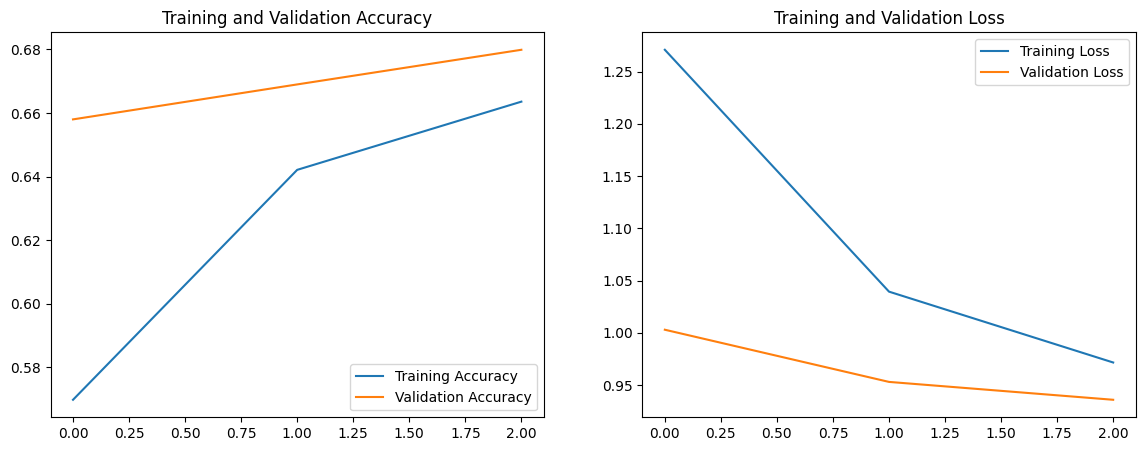

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()